# mpl-llm-selector Usage Demonstration

This notebook demonstrates how to use the `mpl-llm-selector` package to select `matplotlib` artists using natural language queries.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks", palette="pastel")

# Load the example tips dataset
tips = sns.load_dataset("tips")

fig, ax = plt.subplots(1, 1, num=1, clear=True)

# Draw a nested boxplot to show bills by day and time
sns.boxplot(x="day", y="total_bill",
            hue="smoker", palette=["m", "g"],
            data=tips, ax=ax)

sns.despine(offset=10, trim=True)

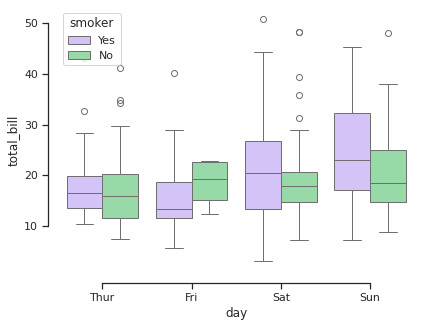

In [9]:
fig

## Selecting Artists with Natural Language

We can use `query_artists` to select artists based on a natural language query.

In [10]:
from mpl_llm_selector import async_query_artists

q = "artists for Friday"
selected = await async_query_artists(ax, q)
print(selected)

SelectedArtists: ['lines[6]', 'lines[7]', 'lines[8]', 'lines[9]', 'lines[10]', 'lines[11]', 'patches[1]', 'lines[30]', 'lines[31]', 'lines[32]', 'lines[33]', 'lines[34]', 'patches[5]']


## Modifying Selected Artists

Once artists are selected, you can modify their properties. Here, we dim the unselected artists.

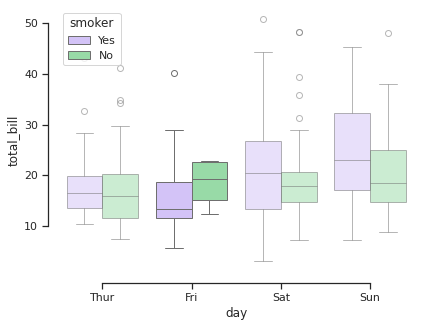

In [11]:
selected.inverted().set(alpha=0.5)

fig

## Hard-coding the selectors

The selectors can be reused (unless you change the plot) thus you may want to hard-code it, instead of querying LLM every run.

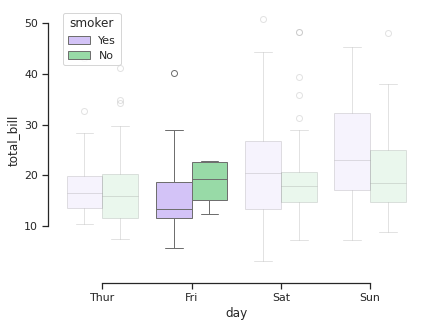

In [12]:
from mpl_llm_selector import from_selectors

selectors = ['lines[6]', 'lines[7]', 'lines[8]', 'lines[9]', 'lines[10]', 'lines[11]',
             'lines[30]', 'lines[31]', 'lines[32]', 'lines[33]', 'lines[34]',
             'patches[1]', 'patches[5]']
selected = from_selectors(ax, selectors)

selected.inverted().set(alpha=0.2)

fig